# Geographic unit assessment — Mérida, Yucatán

This assessment compares candidate reporting units, profiles the 2020 INEGI Marco Geoestadístico layers, maps Mérida's urban AGEBs, and checks DENUE point assignment. It uses raw files as read-only inputs and writes only the study-area map under `outputs/maps/`.

## Candidate-unit decision

| Unit | Census availability | Official polygons | Shared identifier | Resolution | Confidentiality suppression | Decision |
|---|---|---|---|---|---|---|
| Municipality | Census totals available | Yes (`31mun.shp`) | `CVEGEO` (5 characters: state + municipality) | Too coarse for within-city patterns | Most aggregate; still cannot recover smaller-unit counts | Reject: loses the project’s required intra-urban comparisons. |
| Locality | Census totals available | Yes (`31l.shp`) | `CVEGEO` (9 characters: state + municipality + locality) | Medium; Mérida city is only one locality | Less exposed than block counts, but too aggregated for useful city mapping | Reject: insufficient spatial detail and not one row per analytical area. |
| **Urban AGEB** | **Census 2020 publishes urban AGEB and block results** | **Yes (`31a.shp`)** | **`CVEGEO` (13 characters) is shared by census and geometry** | **Fine-grained neighborhood-scale units; 526 units in municipality 050** | Census `*`/`N/D` remain suppressed and must be NULL, never interpreted as zero | **Select: exact common grain, stable key, official valid polygons, and appropriate detail for comparable KPIs.** |
| Urban block (manzana) | Census 2020 results available | Yes (urban block layer) | Composite INEGI key including the 3-character block code (16 characters) | Finest published urban unit | Greatest small-cell disclosure risk; suppressed values are frequent and must remain NULL | Reject as primary unit: finer than needed and more vulnerable to sparse/suppressed counts. |
| Colonia | Not a consistent INEGI census reporting grain | No consistent official colonia polygon layer | No reliable census-to-colonia shared key | Familiar neighborhood label, but boundaries vary by source | Assigning aggregate data creates disclosure and allocation concerns | Reject: cannot reproducibly join census indicators to a canonical boundary. |
| Hex grid | No direct census results | No official census hexagons; must be generated | No native shared key; a grid ID would be project-specific | Configurable and uniform | Census values need areal interpolation, which can obscure suppression and imply false precision | Reject: adds modelling/allocation assumptions without improving source compatibility. |

The selected grain is **urban AGEB**, matching the project data contract and `dw.dim_geography`. Keep suppressed census cells explicit: transform `*` and `N/D` to NULL, count them, and never replace them with zero. The Marco Geoestadístico 2020 source is the official polygon reference; the 2020 census aggregate is the population reference.

In [1]:
from pathlib import Path
import sys

ROOT = next((parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "src" / "config.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the repository root from the notebook working directory")
sys.path.insert(0, str(ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from src.config import CRS_PROJECTED, CVE_ENT, CVE_MUN, DATA_RAW, OUTPUT_MAPS

MARCO_GEO = DATA_RAW / "marco_geo_2020" / "conjunto_de_datos"
AGEB_PATH = MARCO_GEO / "31a.shp"
LOCALITY_PATH = MARCO_GEO / "31l.shp"
MUNICIPALITY_PATH = MARCO_GEO / "31mun.shp"

assert all(path.exists() for path in (AGEB_PATH, LOCALITY_PATH, MUNICIPALITY_PATH))

In [2]:
layers = {
    "31a.shp (urban AGEB)": gpd.read_file(AGEB_PATH),
    "31l.shp (locality)": gpd.read_file(LOCALITY_PATH),
    "31mun.shp (municipality)": gpd.read_file(MUNICIPALITY_PATH),
}

for layer_name, layer in layers.items():
    key_lengths = layer["CVEGEO"].astype(str).str.len().value_counts().sort_index().to_dict()
    print(
        f"{layer_name}: rows={len(layer):,}, CRS={layer.crs}, "
        f"CRS EPSG={layer.crs.to_epsg()}, valid={int(layer.geometry.is_valid.sum()):,}/{len(layer):,}, "
        f"geometry types={layer.geom_type.value_counts().to_dict()}, "
        f"CVEGEO lengths={key_lengths}, unique={layer['CVEGEO'].is_unique}"
    )

    if layer.crs is None or not layer.crs.is_projected:
        raise ValueError(f"Expected the source .prj to describe projected coordinates: {layer_name}")
    # Marco Geoestadístico's .prj is a projected metre CRS; its WKT may not expose an EPSG code.
    layers[layer_name] = layer.to_crs(CRS_PROJECTED)

print(f"Normalized analysis CRS: {CRS_PROJECTED}; the source .prj files describe projected metre coordinates but do not resolve directly to an EPSG authority code.")
ageb_source = layers["31a.shp (urban AGEB)"]
locality_source = layers["31l.shp (locality)"]
municipality_source = layers["31mun.shp (municipality)"]
assert ageb_source.crs.to_epsg() == 6372
assert locality_source.crs.to_epsg() == 6372
assert municipality_source.crs.to_epsg() == 6372
assert ageb_source["CVEGEO"].astype(str).eq(
    ageb_source["CVE_ENT"].astype(str) + ageb_source["CVE_MUN"].astype(str)
    + ageb_source["CVE_LOC"].astype(str) + ageb_source["CVE_AGEB"].astype(str)
).all()
assert locality_source["CVEGEO"].astype(str).eq(
    locality_source["CVE_ENT"].astype(str) + locality_source["CVE_MUN"].astype(str)
    + locality_source["CVE_LOC"].astype(str)
).all()
assert municipality_source["CVEGEO"].astype(str).eq(
    municipality_source["CVE_ENT"].astype(str) + municipality_source["CVE_MUN"].astype(str)
).all()
assert ageb_source.geometry.is_valid.all()
assert locality_source.geometry.is_valid.all()
assert municipality_source.geometry.is_valid.all()

print("CVEGEO structure: state(2) + municipality(3) + locality(4) + AGEB(4) = 13 characters.")
print("Locality CVEGEO = first 9 characters; municipality CVEGEO = first 5 characters.")
print(ageb_source[["CVEGEO", "CVE_ENT", "CVE_MUN", "CVE_LOC", "CVE_AGEB"]].head(3).to_string(index=False))

31a.shp (urban AGEB): rows=1,532, CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], CRS EPSG=None, valid=1,532/1,532, geometry types={'Polygon': 1531, 'MultiPolygon': 1}, CVEGEO lengths={13: 1532}, unique=True


31l.shp (locality): rows=655, CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["ITRF2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], CRS EPSG=None, valid=655/655, geometry types={'Polygon': 646, 'MultiPolygon': 9}, CVEGEO lengths={9: 655}, unique=True
31mun.shp (municipality): rows=106, CRS=PROJCS["MEXICO_ITRF_2008_LCC",GEOGCS["MEXICO_ITRF_2008",DATUM["International_Terrestrial_Reference_Frame_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1061"]],PRIMEM["

Normalized analysis CRS: EPSG:6372; the source .prj files describe projected metre coordinates but do not resolve directly to an EPSG authority code.
CVEGEO structure: state(2) + municipality(3) + locality(4) + AGEB(4) = 13 characters.
Locality CVEGEO = first 9 characters; municipality CVEGEO = first 5 characters.
       CVEGEO CVE_ENT CVE_MUN CVE_LOC CVE_AGEB
3100100010130      31     001    0001     0130
3100100010145      31     001    0001     0145
3100100010164      31     001    0001     0164


CVE_MUN='050': 526 urban AGEBs; 483 city-core; 259.8629 km²


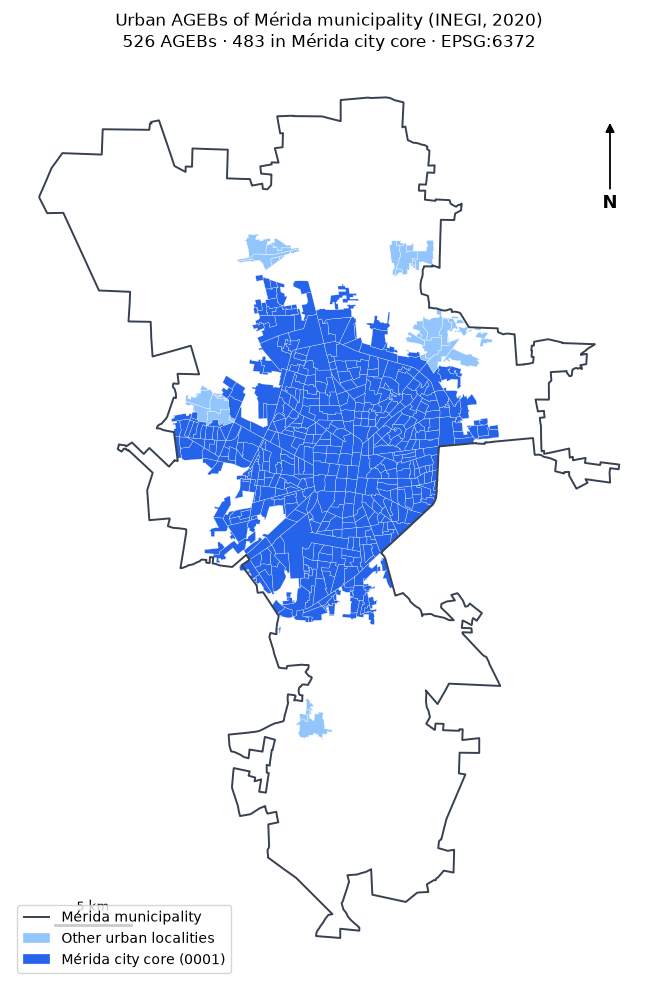

Saved C:\Users\Usuario\merida-urban-intelligence\outputs\maps\00_study_area.png


In [3]:
ageb_merida = ageb_source.loc[
    ageb_source["CVE_ENT"].astype(str).eq(CVE_ENT)
    & ageb_source["CVE_MUN"].astype(str).eq("050")
].copy()
locality_merida = locality_source.loc[
    locality_source["CVE_ENT"].astype(str).eq(CVE_ENT)
    & locality_source["CVE_MUN"].astype(str).eq(CVE_MUN)
]
municipality_merida = municipality_source.loc[
    municipality_source["CVE_ENT"].astype(str).eq(CVE_ENT)
    & municipality_source["CVE_MUN"].astype(str).eq(CVE_MUN)
]
ageb_merida["is_city_core"] = ageb_merida["CVE_LOC"].astype(str).eq("0001")

assert len(ageb_merida) == 526
assert int(ageb_merida["is_city_core"].sum()) == 483
assert ageb_merida["CVEGEO"].is_unique
assert ageb_merida["CVEGEO"].astype(str).str.len().eq(13).all()
assert ageb_merida.geometry.is_valid.all()

area_km2 = ageb_merida.geometry.area.sum() / 1_000_000
print(f"CVE_MUN='050': {len(ageb_merida)} urban AGEBs; {int(ageb_merida.is_city_core.sum())} city-core; {area_km2:.4f} km²")
assert abs(area_km2 - 259.86) <= 0.1

OUTPUT_MAPS.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 10))
municipality_merida.boundary.plot(ax=ax, color="#374151", linewidth=1.4, label="Mérida municipality")
ageb_merida.loc[~ageb_merida.is_city_core].plot(
    ax=ax, color="#93c5fd", edgecolor="white", linewidth=0.25, label="Other urban localities"
)
ageb_merida.loc[ageb_merida.is_city_core].plot(
    ax=ax, color="#2563eb", edgecolor="white", linewidth=0.2, label="Mérida city core (0001)"
)
ax.annotate("N", xy=(0.94, 0.93), xytext=(0.94, 0.84), xycoords="axes fraction",
            ha="center", va="center", fontsize=13, fontweight="bold",
            arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.3})
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
scale_y = ymin + (ymax - ymin) * 0.06
scale_x = xmin + (xmax - xmin) * 0.07
ax.plot([scale_x, scale_x + 5_000], [scale_y, scale_y], color="black", linewidth=2)
ax.text(scale_x + 2_500, scale_y + (ymax - ymin) * 0.015, "5 km", ha="center", fontsize=9)
ax.set_title("Urban AGEBs of Mérida municipality (INEGI, 2020)\n526 AGEBs · 483 in Mérida city core · EPSG:6372")
ax.legend(loc="lower left", frameon=True)
ax.set_axis_off()
fig.tight_layout()
map_path = OUTPUT_MAPS / "00_study_area.png"
fig.savefig(map_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {map_path}")

In [4]:
from src.transform.spatial import assign_ageb, points_from_latlon

denue_path = DATA_RAW / "denue_31" / "conjunto_de_datos" / "denue_inegi_31_.csv"
denue = pd.read_csv(denue_path, encoding="latin-1", dtype=str)
assert {"id", "latitud", "longitud", "cve_mun"}.issubset(denue.columns)

# A deterministic Mérida sample is the point-in-polygon proof of concept.
sample = denue.loc[denue["cve_mun"].eq("050")].sample(
    n=min(1_000, int(denue["cve_mun"].eq("050").sum())), random_state=2020
)
sample_points = points_from_latlon(sample, "latitud", "longitud")
sample_assigned = assign_ageb(sample_points)
print(f"DENUE reproducible sample: {len(sample_assigned)} of {len(sample_points)} valid points assigned.")
assert sample_assigned["id"].is_unique
assert sample_assigned["cvegeo"].notna().all()

# Full-file acceptance check from TEAM_PLAN §4.4.
denue_points = points_from_latlon(denue, "latitud", "longitud")
denue_assigned = assign_ageb(denue_points)
print(f"Full DENUE acceptance: {len(denue_assigned):,} assigned records; no duplicate IDs={denue_assigned['id'].is_unique}.")
assert len(denue_assigned) == 56_667
assert denue_assigned["id"].is_unique
assert denue_assigned["cvegeo"].notna().all()

Dropped 0 invalid/out-of-Yucatán coordinates from 1000 rows.
kept 995 / 1000 (99.5%)
DENUE reproducible sample: 995 of 1000 valid points assigned.


Dropped 1 invalid/out-of-Yucatán coordinates from 146384 rows.


kept 56667 / 146383 (38.7%)
Full DENUE acceptance: 56,667 assigned records; no duplicate IDs=True.


## Assessment result and acceptance

The source layer has 526 valid municipality-050 AGEB polygons, all with a unique 13-character key and no missing locality names; 483 belong to locality `0001`. After projection to EPSG:6372, their combined area is approximately 259.86 km². The study-area map is written to `outputs/maps/00_study_area.png`. The deterministic DENUE sample and the full state file exercise strict `within` assignment; the full acceptance target is 56,667 assigned establishments with unique DENUE IDs and no duplicate join rows.

The parcel geometry and DENUE records are read-only inputs. Transform outputs are written beneath `data/processed/`; the notebook does not modify any raw data.